In [1]:
from elevador import *
import elevador as elv
import numpy as np

# Questão 1
**O codigo original tem um número fixo de elevadores, precisamos dar a volta por isso.**

In [2]:
def simular(n_elv, n_ciclos):
    init_original = elv.init_sim # a ideia é substituir a função de inicialização para podermos alterar essa lógica
    def init_sim_novo():
        elv.POPULAÇÃO.clear() #seguindo a estrutura do codigo original
        elv.FILAS_DE_ANDAR.clear()
        estado_e = [
            dict(andar_ant=0, andar=0, npass=0, passageiros=[], direção=0, chamadas=[])
            for _ in range(n_elv)
        ] # aqui permitimos a quantidade de elevadores ser variável
        estado_sim = dict(fila=0, energia=0.0, viagens=0) # novamente segue a estrutura
        for i in range(1, elv.ANDARES + 1):
            elv.POPULAÇÃO[i]
        return estado_e, estado_sim # ...

    elv.init_sim = init_sim_novo # substituimos
    elv.DESEMBARCADOS = 0
    elv.EMBARCADOS = 0
    elv.CICLOS = 0
    elv.ANDARES_PERCORRIDOS = 0
    elv.loop_de_evento(n_ciclos) # rodamos a simulação
    elv.init_sim = init_original # no final, restauramos a função pra evitar comportamentos estranhos no código original


**Agora podemos realizar nossa simulação com uma quantidade variável de elevadores, como segue:**

In [3]:
simular(n_elv=22,n_ciclos=100)

100:Tamanho da fila: 1; Embarcados: 191; Desembarcados: 182; Andares Percorridos: 7261; Eficiência: 0.025065417986503236


**Sendo assim, agora só precisamos mostrar o gráfico:**

100:Tamanho da fila: 143; Embarcados: 49; Desembarcados: 43; Andares Percorridos: 193; Eficiência: 0.22279792746113988
100:Tamanho da fila: 141; Embarcados: 51; Desembarcados: 51; Andares Percorridos: 205; Eficiência: 0.24878048780487805
100:Tamanho da fila: 139; Embarcados: 53; Desembarcados: 46; Andares Percorridos: 187; Eficiência: 0.24598930481283424
100:Tamanho da fila: 136; Embarcados: 56; Desembarcados: 50; Andares Percorridos: 195; Eficiência: 0.2564102564102564
100:Tamanho da fila: 137; Embarcados: 55; Desembarcados: 54; Andares Percorridos: 213; Eficiência: 0.2535211267605634
100:Tamanho da fila: 142; Embarcados: 50; Desembarcados: 49; Andares Percorridos: 193; Eficiência: 0.2538860103626943
100:Tamanho da fila: 149; Embarcados: 43; Desembarcados: 37; Andares Percorridos: 176; Eficiência: 0.21022727272727273
100:Tamanho da fila: 133; Embarcados: 59; Desembarcados: 53; Andares Percorridos: 196; Eficiência: 0.27040816326530615
100:Tamanho da fila: 141; Embarcados: 51; Desembarc

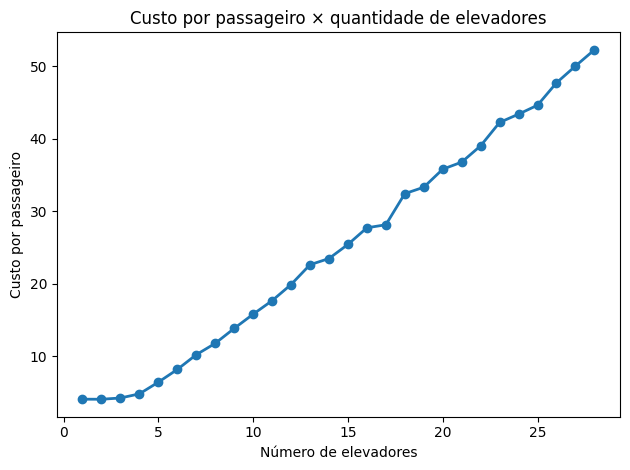

In [4]:
MAX_ELEVADORES = ANDARES*2 # vamos analisar até 2 elevadores por andar
q_elevadores = list(range(1, MAX_ELEVADORES + 1))
custo = []
for n in q_elevadores:
    n_ANDARES_PERCORRIDOS = 0
    n_DESEMBARCADOS = 0
    for i in range(0,10): # vou rodar 10 vezes pra deixar nosso gráfico mais preciso.
        simular(n_elv=n,n_ciclos=100) # para cada valor na lista de qntd de elevadores, rodamos 100 ciclos da simulação
        n_ANDARES_PERCORRIDOS += elv.ANDARES_PERCORRIDOS
        n_DESEMBARCADOS += elv.DESEMBARCADOS
    custo.append(n_ANDARES_PERCORRIDOS / n_DESEMBARCADOS) # O custo por passageiro, ou seja quantos andares percorremos p/ cada pessoa
plt.plot(q_elevadores, custo, marker='o', linewidth=2)
plt.xlabel('Número de elevadores')
plt.ylabel('Custo por passageiro')
plt.title('Custo por passageiro × quantidade de elevadores')
plt.tight_layout() # pra dar uma abrida no gráfico
plt.show()

# Questão 2
**Vamos começar com a fila no térreo.**

100:Tamanho da fila: 145; Embarcados: 47; Desembarcados: 47; Andares Percorridos: 208; Eficiência: 0.22596153846153846
100:Tamanho da fila: 137; Embarcados: 55; Desembarcados: 55; Andares Percorridos: 197; Eficiência: 0.27918781725888325
100:Tamanho da fila: 139; Embarcados: 53; Desembarcados: 49; Andares Percorridos: 206; Eficiência: 0.23786407766990292
100:Tamanho da fila: 137; Embarcados: 55; Desembarcados: 49; Andares Percorridos: 198; Eficiência: 0.2474747474747475
100:Tamanho da fila: 141; Embarcados: 51; Desembarcados: 48; Andares Percorridos: 176; Eficiência: 0.2727272727272727
100:Tamanho da fila: 136; Embarcados: 56; Desembarcados: 48; Andares Percorridos: 189; Eficiência: 0.25396825396825395
100:Tamanho da fila: 137; Embarcados: 55; Desembarcados: 51; Andares Percorridos: 225; Eficiência: 0.22666666666666666
100:Tamanho da fila: 141; Embarcados: 51; Desembarcados: 51; Andares Percorridos: 193; Eficiência: 0.26424870466321243
100:Tamanho da fila: 137; Embarcados: 55; Desembar

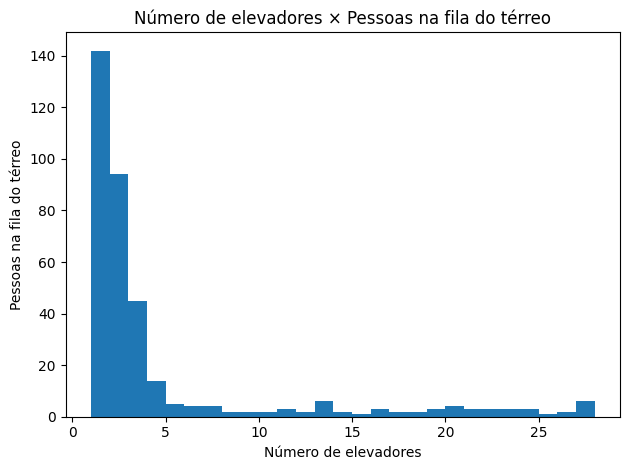

In [5]:
MAX_ELEVADORES = ANDARES*2 # vamos analisar até 2 elevadores por andar
q_elevadores = list(range(1, MAX_ELEVADORES + 1))
fila = []
for n in q_elevadores:
    n_Fila = 0
    for i in range(0,10): # vou rodar 10 vezes pra deixar nosso gráfico mais preciso.
        simular(n_elv=n,n_ciclos=100) # para cada valor na lista de qntd de elevadores, rodamos 100 ciclos da simulação
        n_Fila += elv.sim['fila']  # como pude perceber no print final, o n° de pessoas esperando no térreo é armazenado aqui 
    filaMédia = int(n_Fila / 10)
    fila.append(filaMédia)
bins = range(1,MAX_ELEVADORES+1) # vamos definir melhor os intervalos desse histograma.
plt.hist(q_elevadores, bins=bins, weights=fila) # desenhemos!
plt.xlabel('Número de elevadores')
plt.ylabel('Pessoas na fila do térreo')
plt.title('Número de elevadores × Pessoas na fila do térreo')
plt.tight_layout() # ...
plt.show()

**Agora temos que visualizar as filas em cada andar do prédio.**

A questão é, como fazer isso? Tenho 14 filas, com quantidade variável de pessoas e um número variável de elevadores \
Depois de pensar um pouco, encontrei duas maneiras, o **mapa de calor** e um **gráfico de linhas múltiplas**. \
Decidi o mapa de calor por elegância.

100:Tamanho da fila: 145; Embarcados: 47; Desembarcados: 46; Andares Percorridos: 170; Eficiência: 0.27058823529411763
100:Tamanho da fila: 95; Embarcados: 97; Desembarcados: 93; Andares Percorridos: 363; Eficiência: 0.256198347107438
100:Tamanho da fila: 59; Embarcados: 133; Desembarcados: 127; Andares Percorridos: 557; Eficiência: 0.22800718132854578
100:Tamanho da fila: 17; Embarcados: 175; Desembarcados: 175; Andares Percorridos: 793; Eficiência: 0.22068095838587642
100:Tamanho da fila: 8; Embarcados: 184; Desembarcados: 176; Andares Percorridos: 1078; Eficiência: 0.16326530612244897
100:Tamanho da fila: 17; Embarcados: 175; Desembarcados: 175; Andares Percorridos: 1582; Eficiência: 0.11061946902654868
100:Tamanho da fila: 1; Embarcados: 191; Desembarcados: 184; Andares Percorridos: 1931; Eficiência: 0.09528741584671155
100:Tamanho da fila: 8; Embarcados: 184; Desembarcados: 180; Andares Percorridos: 2247; Eficiência: 0.0801068090787717
100:Tamanho da fila: 1; Embarcados: 191; Dese

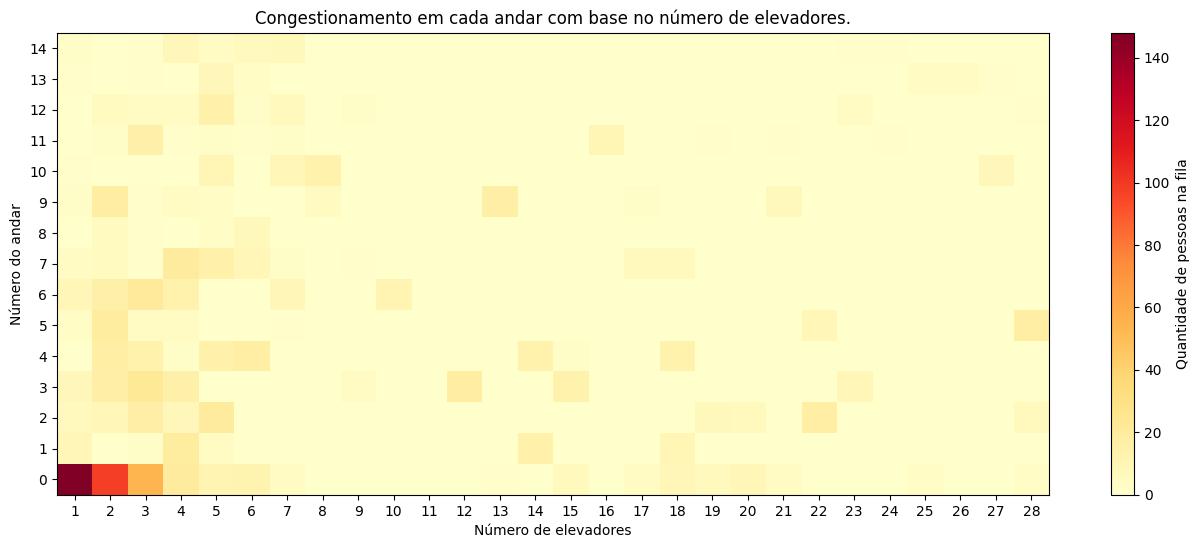

In [6]:
MAX_ELEVADORES = ANDARES*2
q_elevadores = list(range(1, MAX_ELEVADORES + 1))
filas_por_andar = {m: [] for m in range(MAX_ELEVADORES + 1)} # dicionario para termos várias listas com vários elevadores!
for n in q_elevadores:
    simular(n_elv=n, n_ciclos=100) # apenas uma iteração dessa vez.
    for m in range(ANDARES + 1):
        filas_por_andar[m].append(
            elv.sim["fila"] if m == 0 else elv.FILAS_DE_ANDAR[m] # por alguma razão o térreo não está incluido no filas_de_andar.
        )
matriz = np.array([filas_por_andar[m] for m in range(ANDARES + 1)])[::-1] # invertido fica que nem em um prédio, com o térreo em baixo
plt.figure(figsize=(16, 6)) # o eixo das abcissas estava se sobrepondo
plt.imshow(matriz, cmap="YlOrRd", aspect="auto") # amarelo, laranja, vermelho e vermelho escuro.
plt.xticks(np.arange(len(q_elevadores)), q_elevadores)
plt.yticks(np.arange(ANDARES + 1), list(range(ANDARES, -1, -1)))
plt.xlabel("Número de elevadores")
plt.ylabel("Número do andar")
plt.title("Congestionamento em cada andar com base no número de elevadores.")
barradecor = plt.colorbar() # barra de cor em relação a quantidade de pessoas.
barradecor.set_label("Quantidade de pessoas na fila") # defini como uma var pra poder por este texto.
plt.show()


Com isso conseguimos ver, que a partir de aproximadamente 5 elevadores, atingimos um balanço no congestionamento de pessoas. \
As porções mais escuras a partir daí são argumentavelmente pseudo-aleatórias.

# Questão 3
Executando o código no elevador_report, observei que o gráfico se comporta de maneira estranha. \
O código a ser exibido abaixo, é o snippet do elevador_report que contém o erro:\
Observe que ao executar o código abaixo é possível ver um gráfico esquisito com várias curvas aglomeradas.

100:Tamanho da fila: 91; Embarcados: 101; Desembarcados: 94; Andares Percorridos: 381; Eficiência: 0.24671916010498687
100:Tamanho da fila: 89; Embarcados: 103; Desembarcados: 103; Andares Percorridos: 401; Eficiência: 0.256857855361596
100:Tamanho da fila: 94; Embarcados: 98; Desembarcados: 95; Andares Percorridos: 414; Eficiência: 0.22946859903381642
100:Tamanho da fila: 78; Embarcados: 114; Desembarcados: 109; Andares Percorridos: 392; Eficiência: 0.2780612244897959
100:Tamanho da fila: 81; Embarcados: 111; Desembarcados: 97; Andares Percorridos: 357; Eficiência: 0.27170868347338933
100:Tamanho da fila: 86; Embarcados: 106; Desembarcados: 97; Andares Percorridos: 381; Eficiência: 0.2545931758530184
100:Tamanho da fila: 88; Embarcados: 104; Desembarcados: 101; Andares Percorridos: 379; Eficiência: 0.26649076517150394
100:Tamanho da fila: 80; Embarcados: 112; Desembarcados: 97; Andares Percorridos: 424; Eficiência: 0.22877358490566038
100:Tamanho da fila: 79; Embarcados: 113; Desembar

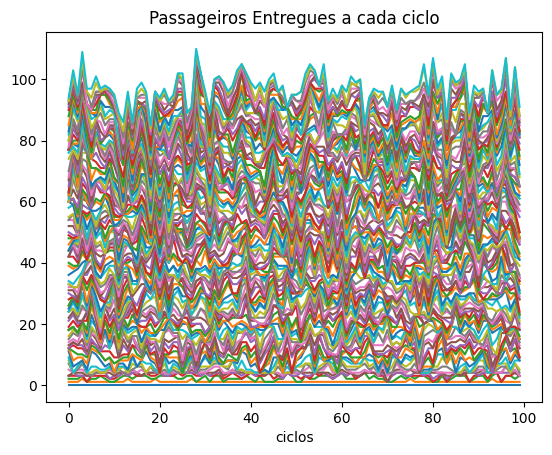

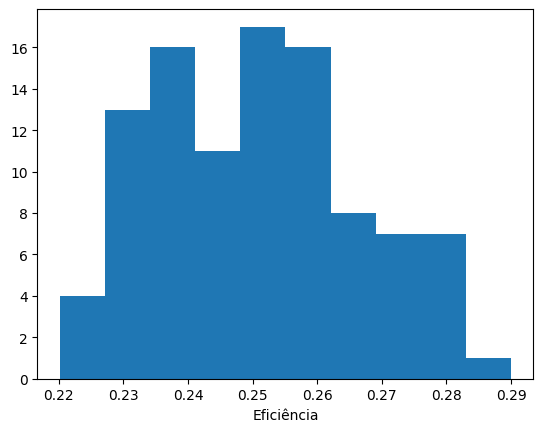

In [ ]:
entregas=[]
eficiências=[]
n = 100
# loop_de_evento(n)
for i in range(100):
    elv.POPULAÇÃO = defaultdict(lambda:0)
    elv.DESEMBARCADOS = 0  # Numero de pessoas entregues em andares != térreo
    elv.EMBARCADOS = 0  # numero total de pessoas que pegaram elevadores durante a simulação
    elv.CICLOS = 0
    elv.ANDARES_PERCORRIDOS = 0
    en,ef = loop_de_evento(100) # aqui está o problema
    entregas.append(en) # aqui está o problema, estamos construindo uma matriz mais ou menos 100x100!
    eficiências.append(ef)
# print(elevadores)
print(elv.POPULAÇÃO)
plt.plot(entregas) # aqui está o problema, estamos plotando a lista de listas em vez de cada uma das listas.
plt.title("Passageiros Entregues a cada ciclo (bugado)")
plt.xlabel("ciclos")
plt.figure()
plt.hist(eficiências)
plt.xlabel("Eficiência")
plt.show()



Deixei comentada as linhas que possuem o problema no CÓDIGO DE CIMA\
Agora para explicar melhor, basta visualizar o que está acontecendo.\
O acúmulo vem de loop_de_evento, que retorna a lista en construída assim:\
entregas.append(DESEMBARCADOS)\
Ou seja as entregas não são calculadas no fim da simulação, ao contrário da eficiência.\
O problema só existe com entregas porque é uma lista de listas, onde cada sublista carrega o acúmulo interno ciclo a ciclo.\
O matplotlib interpreta os dados incorretamente por conta disso.

100:Tamanho da fila: 94; Embarcados: 98; Desembarcados: 90; Andares Percorridos: 407; Eficiência: 0.22113022113022113
100:Tamanho da fila: 86; Embarcados: 106; Desembarcados: 104; Andares Percorridos: 369; Eficiência: 0.28184281842818426
100:Tamanho da fila: 93; Embarcados: 99; Desembarcados: 95; Andares Percorridos: 356; Eficiência: 0.26685393258426965
100:Tamanho da fila: 86; Embarcados: 106; Desembarcados: 95; Andares Percorridos: 379; Eficiência: 0.25065963060686014
100:Tamanho da fila: 90; Embarcados: 102; Desembarcados: 95; Andares Percorridos: 370; Eficiência: 0.25675675675675674
100:Tamanho da fila: 85; Embarcados: 107; Desembarcados: 100; Andares Percorridos: 394; Eficiência: 0.25380710659898476
100:Tamanho da fila: 98; Embarcados: 94; Desembarcados: 94; Andares Percorridos: 354; Eficiência: 0.2655367231638418
100:Tamanho da fila: 89; Embarcados: 103; Desembarcados: 90; Andares Percorridos: 377; Eficiência: 0.23872679045092837
100:Tamanho da fila: 84; Embarcados: 108; Desembar

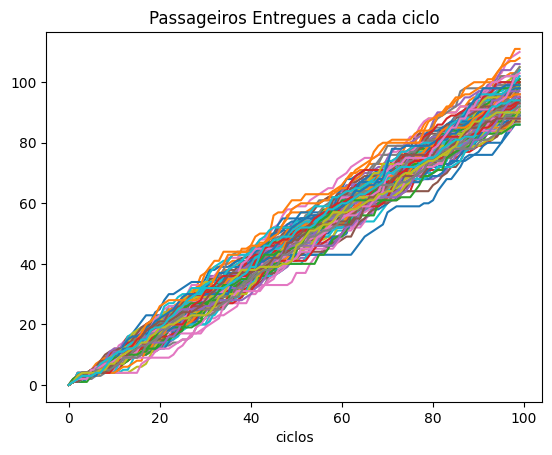

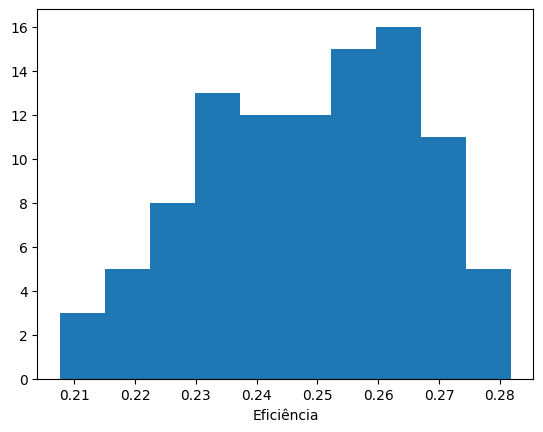

In [47]:
entregas=[]
eficiências=[]
n = 100
# loop_de_evento(n)
for i in range(100):
    elv.POPULAÇÃO = defaultdict(lambda:0)
    elv.DESEMBARCADOS = 0  # Numero de pessoas entregues em andares != térreo
    elv.EMBARCADOS = 0  # numero total de pessoas que pegaram elevadores durante a simulação
    elv.CICLOS = 0
    elv.ANDARES_PERCORRIDOS = 0
    en,ef = loop_de_evento(100)
    entregas.append(en)
    eficiências.append(ef)
    plt.plot(entregas[i]) # Consertamos plotando uma lista de cada vez, assim tendo mais ou menos 100 linhas ao em vez da "matriz bugada".
# print(elevadores)
print(elv.POPULAÇÃO)
plt.title("Passageiros Entregues a cada ciclo")
plt.xlabel("ciclos")
plt.figure()
plt.hist(eficiências)
plt.xlabel("Eficiência")
plt.show()

Observe agora que tivemos 100 linhas, como queríamos antes.\
Podemos é claro plotar apenas a primeira entrega ou algumas, mas para preservar o código original, resolvi plotar as 100 linhas mesmo.

# Com isso este trabalho está completo.